# 14 · Systems of nonlinear equations

**Problem - the three-reservoir problem.** Three reservoirs at different levels are connected by pipes
to a common junction. What is the pressure head at the junction, and how much water flows in each pipe -
and in which direction? Each pipe obeys the energy equation (head loss $\propto Q|Q|$), and the flows
must balance at the junction:
$$z_i - H = k_i\,Q_i\,|Q_i|\quad (i = 1, 2, 3),\qquad Q_1 + Q_2 + Q_3 = 0,\qquad k_i = \frac{8 f L_i}{g\pi^2 D_i^5},$$
with $Q_i$ the flow from reservoir $i$ towards the junction. Four nonlinear equations in four unknowns
$(H, Q_1, Q_2, Q_3)$.

**What you will learn**

- formulate an engineering network as a system of nonlinear equations
- implement Newton's method for systems and observe quadratic convergence
- check a solution by an independent formulation
- understand basins of attraction and why line searches help

**Before you start:** notebooks 02 (root finding) and 03 (linear systems); partial derivatives  ·  **Time:** about 60 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import nonlinear, roots

In [2]:
z = np.array([120.0, 100.0, 60.0])              # reservoir levels (m)
Lp = np.array([1000.0, 800.0, 1200.0])            # pipe lengths (m)
Dp = np.array([0.30, 0.25, 0.20])                 # diameters (m)
f_darcy, g = 0.02, 9.81
k = 8 * f_darcy * Lp / (g * np.pi**2 * Dp**5)

def F(v):
    H, Q = v[0], v[1:]
    return np.r_[z - H - k * Q * np.abs(Q), Q.sum()]

sol = nonlinear.newton_system(F, [90.0, 0.1, 0.0, -0.1])
print(sol)
H, Q = sol.x[0], sol.x[1:]
print(f"junction head H = {H:.2f} m")
for i, q in enumerate(Q, start=1):
    direction = "from the reservoir into the junction" if q > 0 else "from the junction into the reservoir"
    print(f"pipe {i}: {abs(q)*1000:6.1f} L/s {direction}")

x = [ 1.05211906e+02  1.47463188e-01 -6.20479888e-02 -8.54151996e-02] (converged in 6 iterations)
junction head H = 105.21 m
pipe 1:  147.5 L/s from the reservoir into the junction
pipe 2:   62.0 L/s from the junction into the reservoir
pipe 3:   85.4 L/s from the junction into the reservoir


Water can flow either way in each pipe, which is why the flows are unknowns with a sign: the solution
tells us which reservoirs supply the network and which are being filled.

## Newton's method for systems
Linearise all equations at once: $F(\mathbf x + \Delta\mathbf x) \approx F(\mathbf x) + J\,\Delta\mathbf x = \mathbf 0$, where
$J_{ij} = \partial F_i/\partial x_j$ is the **Jacobian**. Each iteration solves one linear system
(notebook 03). Near the solution the error is roughly squared at every step:

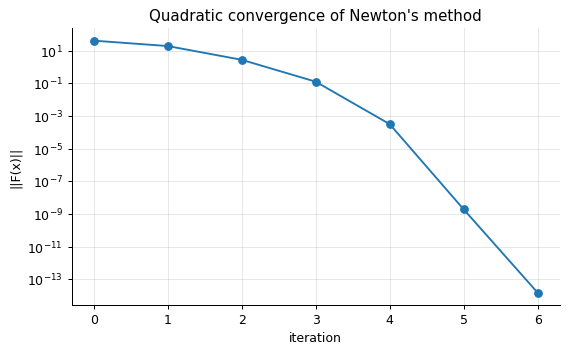

In [3]:
plt.semilogy(sol.residual_history, "o-")
plt.xlabel("iteration"); plt.ylabel("||F(x)||"); plt.title("Quadratic convergence of Newton's method"); plt.show()

## Inside the algorithm: Newton's method for systems
Each iteration: evaluate $F$, build the Jacobian column by column with finite differences, solve
$J\,\Delta x = -F$, update:

In [4]:
def newton_by_hand(F, x, tol=1e-10):
    x = np.array(x, float)
    for it in range(1, 30):
        f = F(x)
        J = np.empty((len(f), len(x)))
        for j in range(len(x)):                        # finite-difference Jacobian, one column at a time
            dx = 1e-7 * max(abs(x[j]), 1.0)
            xp = x.copy(); xp[j] += dx
            J[:, j] = (F(xp) - f) / dx
        x = x + np.linalg.solve(J, -f)
        print(f"iteration {it}: ||F|| = {np.linalg.norm(F(x)):.2e}")
        if np.linalg.norm(F(x)) < tol:
            return x

x_hand = newton_by_hand(F, [90.0, 0.1, 0.0, -0.1])
print("max difference from the library:", np.max(np.abs(x_hand - sol.x)))

iteration 1: ||F|| = 1.90e+01
iteration 2: ||F|| = 2.74e+00
iteration 3: ||F|| = 1.26e-01
iteration 4: ||F|| = 3.19e-04
iteration 5: ||F|| = 1.96e-09
iteration 6: ||F|| = 1.56e-14
max difference from the library: 0.0


## Checking the answer independently
Here the flows can be eliminated: $Q_i = \mathrm{sign}(z_i - H)\sqrt{|z_i - H|/k_i}$, leaving one equation for
$H$ (continuity), which Brent's method (notebook 02) solves reliably.

In [5]:
continuity = lambda H: np.sum(np.sign(z - H) * np.sqrt(np.abs(z - H) / k))
H_check = roots.brent(continuity, z.min(), z.max()).root
print(f"Newton (4 unknowns): H = {H:.10f} m\nBrent  (1 unknown):  H = {H_check:.10f} m")

Newton (4 unknowns): H = 105.2119062115 m
Brent  (1 unknown):  H = 105.2119062115 m


Reducing a system to fewer unknowns is always worth trying, but real networks (dozens of pipes,
loops, pumps) cannot be reduced by hand - Newton's method for systems is the workhorse.

## Starting values and basins of attraction
A nonlinear system may have several solutions; which one Newton finds depends on the start. The
system $x^2 + y^2 = 4$, $xy = 1$ has four solutions (a circle meets a hyperbola). Colouring each starting
point by the solution it converges to reveals the **basins of attraction**:

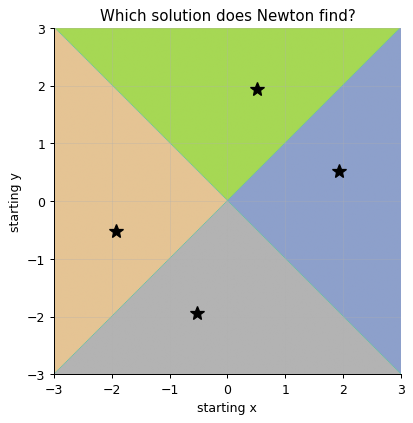

0.5 % of the starting points do not converge within 30 iterations


In [6]:
def newton_grid(x, y, iters=30):
    # vectorised Newton on a whole grid of starting points (analytic Jacobian, no line search)
    with np.errstate(all="ignore"):                  # some starts blow up - expected
        for _ in range(iters):
            f1, f2 = x**2 + y**2 - 4, x*y - 1
            a, b, c, d = 2*x, 2*y, y, x              # Jacobian [[a, b], [c, d]]
            det = a*d - b*c
            x, y = x - (d*f1 - b*f2)/det, y - (-c*f1 + a*f2)/det
    return x, y

g1 = np.linspace(-3, 3, 400)
X0, Y0 = np.meshgrid(g1, g1)
XE, YE = newton_grid(X0, Y0)
r1, r2 = np.sqrt(2 + np.sqrt(3)), np.sqrt(2 - np.sqrt(3))       # exact solutions (±r1, ±r2), (±r2, ±r1)
sols = np.array([[r1, r2], [r2, r1], [-r1, -r2], [-r2, -r1]])
dist = np.stack([np.hypot(XE - sx, YE - sy) for sx, sy in sols])
dist = np.nan_to_num(dist, nan=np.inf)
basin = np.where(dist.min(axis=0) < 1e-6, dist.argmin(axis=0), -1)
plt.figure(figsize=(5.5, 5))
plt.imshow(basin, extent=[-3, 3, -3, 3], origin="lower", cmap="Set2")
plt.plot(sols[:, 0], sols[:, 1], "k*", ms=12)
plt.xlabel("starting x"); plt.ylabel("starting y"); plt.title("Which solution does Newton find?")
plt.show()
print(f"{np.mean(basin == -1)*100:.1f} % of the starting points do not converge within 30 iterations")

Near the lines $y = \pm x$, where the Jacobian is singular, the basins interleave in intricate patterns:
a tiny change of starting point can lead to a different solution. **Always check that the solution
found is the physically meaningful one**, and take starting values from physics (here: the junction
head must lie between the lowest and the highest reservoir).

## Robustness: the line search
Plain Newton can overshoot wildly. `newton_system` halves the step until the residual really decreases
(a *line search*), which rescues many poor starting points:

In [7]:
Fbad = lambda v: [np.arctan(v[0]), v[1] - 0.1]
for ls in (False, True):
    r = nonlinear.newton_system(Fbad, [3.0, 1.0], line_search=ls, maxiter=30)
    print(f"line search {ls!s:5}: {r}")

line search False: x = [8.97645219e+08 1.00000000e-01] (NOT converged in 5 iterations)
line search True : x = [-1.32348898e-23  1.00000000e-01] (converged in 10 iterations)


## In practice
`scipy.optimize.root` offers several robust solvers (a hybrid Powell method by default):

In [8]:
from scipy.optimize import root
ref = root(F, [90.0, 0.1, 0.0, -0.1])
print("scipy:", np.round(ref.x, 10), "\nours: ", np.round(sol.x, 10))

scipy: [ 1.05211906e+02  1.47463188e-01 -6.20479888e-02 -8.54151996e-02] 
ours:  [ 1.05211906e+02  1.47463189e-01 -6.20479888e-02 -8.54151996e-02]


## Exercises
1. Replace the constant friction factor by the Colebrook equation (notebook 02) for each pipe
   (commercial steel, $\varepsilon$ = 0.045 mm; water $\nu$ = 1.0 × 10⁻⁶ m²/s), which puts a root solve
   inside every evaluation of $F$. How much do the flows change?
2. Add a fourth reservoir at 90 m, connected by a 900 m, 0.25 m pipe. Which reservoirs now supply water?
3. Start from $H = 150$ m (above every reservoir). Does Newton still find the solution, with and without
   the line search? Look at the residual history to explain.
4. **Implement it yourself:** Broyden's method avoids recomputing the Jacobian: after each step update it with $J \leftarrow J + \frac{(\Delta F - J\Delta x)\Delta x^T}{\Delta x^T\Delta x}$. Implement it for the reservoir problem and compare the number of function evaluations with Newton's method.